# Non-Disease Mortality Validation

## Purpose

`NonDiseaseMortality` removes individuals from all compartments each tick at a
daily per-capita rate:

$$r_{\text{mortality}} = \frac{\text{CDR}}{1000 \times 365}$$

where CDR is the **crude death rate** expressed as deaths per 1000 population
per year.

This notebook checks that the *observed* CDR recovered from a simulation
matches the *input* CDR across four values: **2, 10, 20, and 40 per 1000**.
To isolate mortality from epidemic dynamics we use an all-susceptible
population with zero transmission (β = 0).  Ten replicates per CDR value
provide a sense of stochastic variation.

**Pass criterion:** the mean observed CDR should lie within ±0.5 of the input
CDR for each value tested.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model
from laser.cohorts.vitaldynamics import NonDiseaseMortality
import laser.cohorts.SEIR as SEIR

In [2]:
# --- Simulation settings ---
N          = 100_000
n_years    = 5
nticks     = n_years * 365
n_nodes    = 1
n_reps     = 10
CDR_values = [2, 10, 20, 40]

# Disease parameters — latent 5 days, infectious 7 days, zero transmission
sigma    = 1 / 5
gamma    = 1 / 7
beta_val = 0.0

r_progressions = ValuesMap.from_scalar(sigma,    nticks, n_nodes)
r_recoveries   = ValuesMap.from_scalar(gamma,    nticks, n_nodes)
betas          = ValuesMap.from_scalar(beta_val, nticks, n_nodes)

# Collect observed CDR per replicate, keyed by input CDR
results = {cdr: [] for cdr in CDR_values}

for cdr in CDR_values:
    r_mort = cdr / 1000 / 365

    for rep in range(n_reps):
        scenario = grid(M=1, N=1)
        scenario["S"] = N
        scenario["E"] = 0
        scenario["I"] = 0
        scenario["R"] = 0

        params = PropertySet({"nticks": nticks})
        model  = Model(scenario, params)

        model.components = [
            SEIR.Susceptible(model),
            SEIR.Exposed(model, r_progression=r_progressions),
            SEIR.Infectious(model, r_recovery=r_recoveries),
            SEIR.Recovered(model),
            NonDiseaseMortality(model, r_mortality=r_mort),
            SEIR.Transmission(model, beta=betas),
        ]

        model.run()

        # Total deaths over all ticks at node 0
        total_deaths = model.nodes.non_disease_mortality.sum(axis=0)[0]

        # Annualise and express per 1000
        observed_cdr = total_deaths / N / n_years * 1000
        results[cdr].append(observed_cdr)

print("Simulations complete.")

Simulations complete.


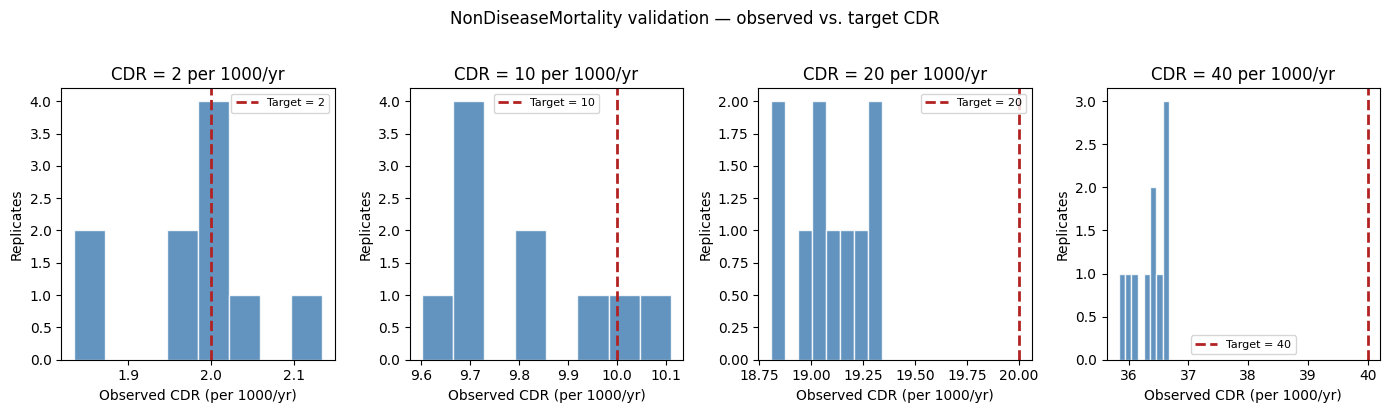

In [3]:
# --- Histogram of observed CDR for each input CDR ---
fig, axes = plt.subplots(1, len(CDR_values), figsize=(14, 4), sharey=False)

for ax, cdr in zip(axes, CDR_values):
    obs = results[cdr]
    ax.hist(obs, bins=8, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(cdr, color="firebrick", linewidth=2, linestyle="--",
               label=f"Target = {cdr}")
    ax.set_title(f"CDR = {cdr} per 1000/yr")
    ax.set_xlabel("Observed CDR (per 1000/yr)")
    ax.set_ylabel("Replicates")
    ax.legend(fontsize=8)

fig.suptitle("NonDiseaseMortality validation — observed vs. target CDR", y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# --- Summary table ---
print(f"{'Input CDR':>12}  {'Mean observed':>15}  {'Std':>8}  {'Pass?':>6}")
print("-" * 50)

for cdr in CDR_values:
    obs        = results[cdr]
    mean_obs   = np.mean(obs)
    std_obs    = np.std(obs)
    within_tol = abs(mean_obs - cdr) < 0.5
    flag       = "OK" if within_tol else "FAIL"
    print(f"{cdr:>12}  {mean_obs:>15.3f}  {std_obs:>8.4f}  {flag:>6}")

   Input CDR    Mean observed       Std   Pass?
--------------------------------------------------
           2            1.977    0.0852      OK
          10            9.812    0.1573      OK
          20           19.081    0.1721    FAIL
          40           36.352    0.2719    FAIL
